In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)


In [ ]:
data_dir = "/content/drive/MyDrive/Lung cancer/The IQ-OTHNCCD lung cancer dataset"

classes = ["Normal cases", "Bengin cases", "Malignant cases"]


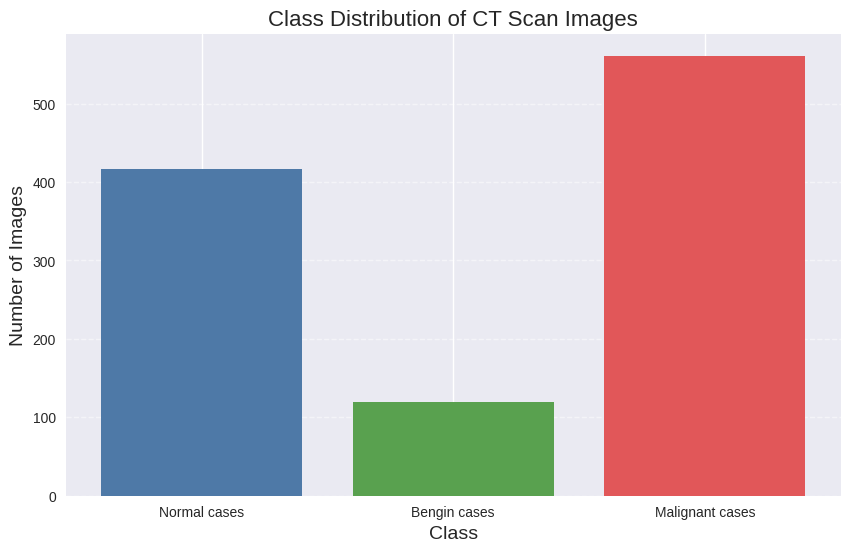

{'Normal cases': 416, 'Bengin cases': 120, 'Malignant cases': 561}

In [ ]:
# Count images in each class directory
class_counts = {}

for cls in classes:
    folder = os.path.join(data_dir, cls)
    class_counts[cls] = len([f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])

# Plot
plt.bar(class_counts.keys(), class_counts.values(), color=['#4e79a7', '#59a14f', '#e15759'])
plt.title("Class Distribution of CT Scan Images", fontsize=16)
plt.xlabel("Class", fontsize=14)
plt.ylabel("Number of Images", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

class_counts


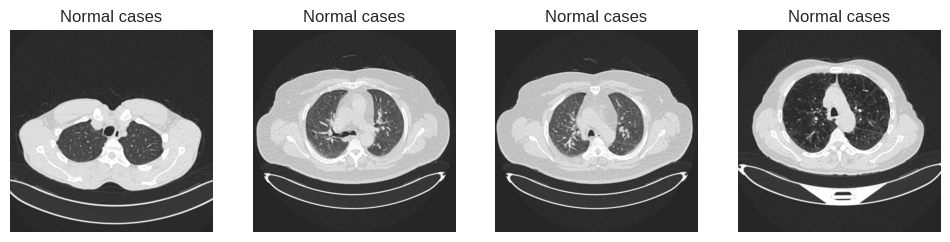

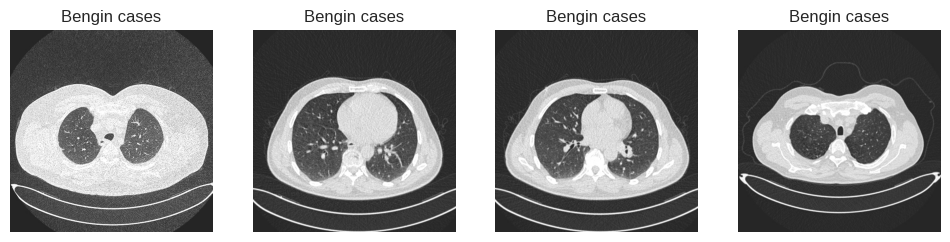

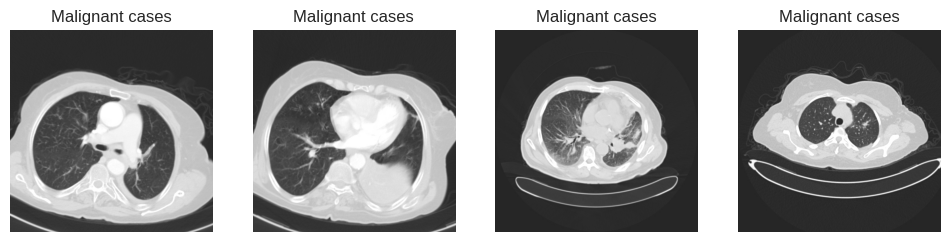

In [ ]:
def show_samples(class_name, n=4):
    folder = os.path.join(data_dir, class_name)
    images = [img for img in os.listdir(folder) if img.endswith(('.jpg', '.png'))]
    plt.figure(figsize=(12, 6))
    for i in range(n):
        img = Image.open(os.path.join(folder, images[i]))
        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(f"{class_name}")
        plt.axis('off')
    plt.show()

# Show samples from each class
for cls in classes:
    show_samples(cls)


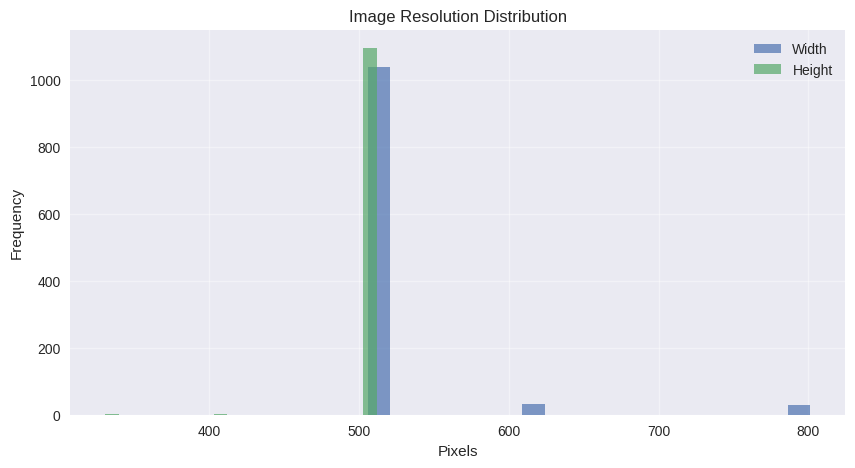

In [ ]:
sizes = []

for cls in classes:
    folder = os.path.join(data_dir, cls)
    for img_name in os.listdir(folder):
        img_path = os.path.join(folder, img_name)
        try:
            with Image.open(img_path) as img:
                sizes.append(img.size)
        except:
            pass

# Convert to numpy for easier analysis
sizes = np.array(sizes)

# Plot width & height distribution
plt.figure(figsize=(10,5))
plt.hist(sizes[:,0], bins=20, alpha=0.7, label='Width')
plt.hist(sizes[:,1], bins=20, alpha=0.7, label='Height')
plt.legend()
plt.title("Image Resolution Distribution")
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.grid(alpha=0.4)
plt.show()


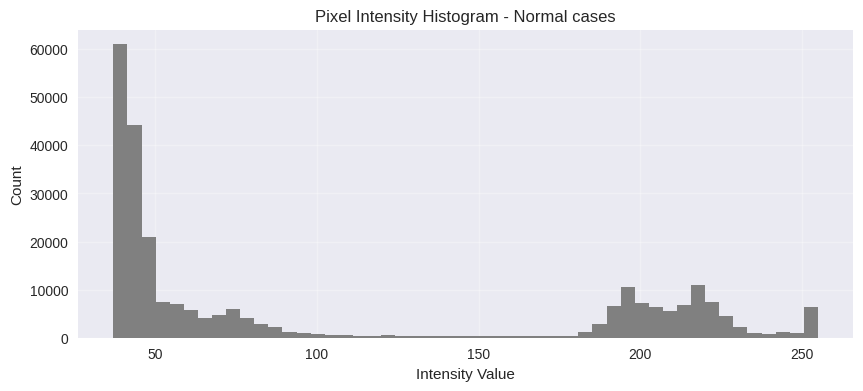

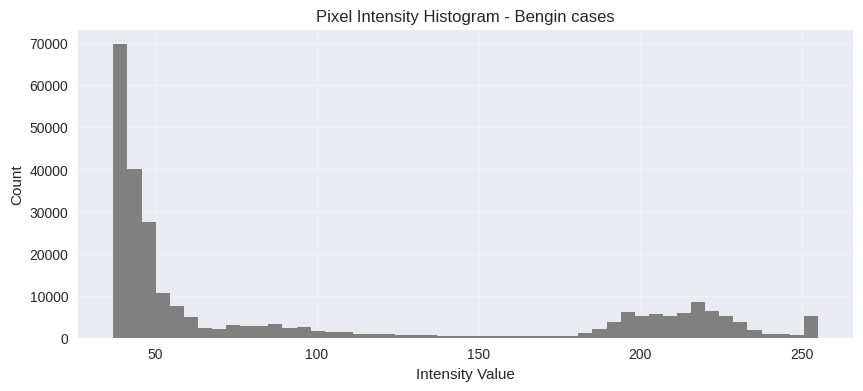

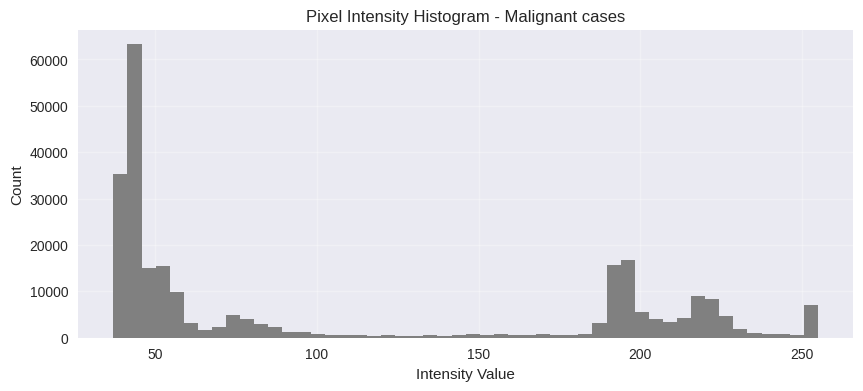

In [ ]:
# Pick a random image from each class
import random

for cls in classes:
    folder = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = cv2.imread(img_path, 0)  # grayscale

    plt.figure(figsize=(10,4))
    plt.hist(img.ravel(), bins=50, color='gray')
    plt.title(f"Pixel Intensity Histogram - {cls}")
    plt.xlabel("Intensity Value")
    plt.ylabel("Count")
    plt.grid(alpha=0.3)
    plt.show()


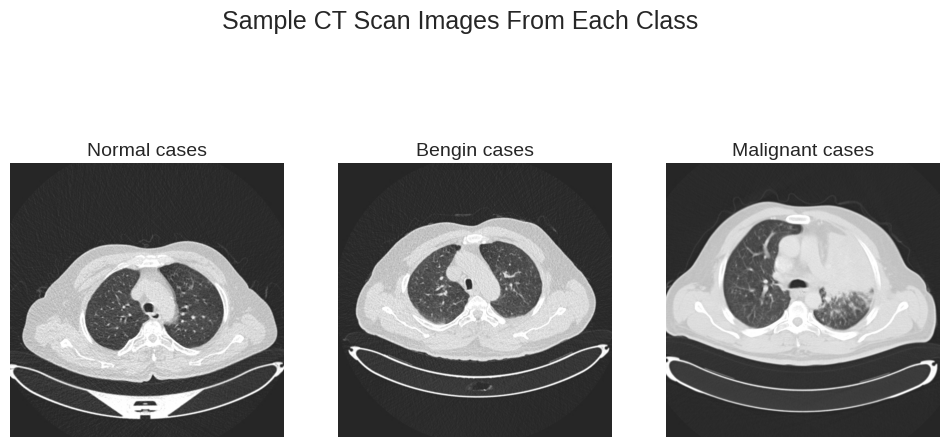

In [ ]:
plt.figure(figsize=(12, 6))

for idx, cls in enumerate(classes):
    folder = os.path.join(data_dir, cls)
    img_name = random.choice(os.listdir(folder))
    img_path = os.path.join(folder, img_name)

    img = Image.open(img_path)

    plt.subplot(1, 3, idx+1)
    plt.imshow(img, cmap='gray')
    plt.title(cls, fontsize=14)
    plt.axis('off')

plt.suptitle("Sample CT Scan Images From Each Class", fontsize=18)
plt.show()
